# MITGCM Transect Kinetic Energy Analysis

**Purpose**: Code for computing the eddy and mean kinetic energy along the CalCOF transect.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import gsw
from geopy.distance import geodesic
from scipy.ndimage import uniform_filter1d
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from scipy.stats import chi2
import matplotlib.colors as mcolors

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from filtering import lanczos_lowpass_filter, butter_lowpass_filter
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series
from spectra import spectrum1D_frequency, spectral_slope, rotary_spectrum_welch
from lsf import unweighted_lsf, detrend
from plotScaleAnalysis import add_freq_marker

Set data analysis parameters

In [52]:
# Set processing parameters
option_energy        = 'FKE'     # Specifies which component of the kinetic energy will be computed
option_filter        = 'butter'  # Specifies which filtering approach to take. Options include 'boxcar', 'butter', 'Lanczos'
option_vel           = 'total'   # Specifies which component of velocity is used in calculation. Options include: 'total', 'baroclinic'
option_lsf           = False      # Specifies whether to apply a least squares fit before computing the KE spectrum or MKE/EKE 

# Set time and space parameters  
dt           = 1*(60)*(60)                   # Time step of the model output in seconds
T_cut        = 30                            # Specifies the cutoff for filtering. Units: days
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 15

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
# Obtain filename paths
filename_u = PATH + "UVEL_CCS4_hrly_transect_calCOFI_line80.nc"
filename_v = PATH + "VVEL_CCS4_hrly_transect_calCOFI_line80.nc"

# Generate the nc data structure
nc_u = Dataset(filename_u, 'r')
nc_v = Dataset(filename_v, 'r')

# Extract data variables
depth  = nc_u.variables['Z'][:]
lon    = nc_v.variables['XC'][:]
lat    = nc_u.variables['YC'][:]
dist   = nc_u.variables['distance'][:] 
time   =  num2date(nc_u.variables['time'][:], nc_u.variables['time'].units)

u_raw  = nc_u.variables['U_center'][:]
v_raw  = nc_v.variables['V_center'][:]

# Mask data at fill values (zero for the MITgcm output)
u_m = np.ma.masked_where(u_raw == 0, u_raw)
v_m = np.ma.masked_where(v_raw == 0, v_raw)

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
u_m = u_m[:,:,::-1]
v_m = v_m[:,:,::-1]

Load mixed layer depth data

In [5]:
filename_mld  = PATH_mld + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat_mld              = ds_mld['lat'] 
lon_mld              = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

Compute cumulative distance along line 80.0 for the mixed layer depth 

In [6]:
# Initialize array 
dist_mld = np.zeros(len(lon_mld))

# Loop through stations 
for i in range(1,len(lon_mld)): 

    # Define i and i + 1 points along transect
    pt1 = (lat_mld[i-1], lon_mld[i-1])
    pt2 = (lat_mld[i],   lon_mld[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

# Find the indices specified by lat and lon bounds
dist_mask = ((lat_mld >= lat_bnds[0]) & (lat_mld <= lat_bnds[1]) & (lon_mld >= lon_bnds[0]) & (lon_mld <= lon_bnds[1]))
idx_dist_mld  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat_mld   = lat_mld[idx_dist_mld]
lon_mld   = lon_mld[idx_dist_mld]
dist_mld  = dist_mld[idx_dist_mld]

Load in the ocean bottom land mask

In [7]:
filename = PATH + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Load the velocity vectors rotated in the cross and along shore coordinate system 

In [8]:
filename_vel = PATH + "mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"
nc_vel = Dataset(filename_vel, 'r')

# Extract data variables
depth_v   = nc_vel.variables['depth'][:]
lon_v     = nc_vel.variables['LON'][:]
lat_v     = nc_vel.variables['LAT'][:]
dist_v    = nc_vel.variables['DIST'][:]     
time_v    =  num2date(nc_vel.variables['time'][:], nc_vel.variables['time'].units)
 
u_along_shore_bar = nc_vel.variables['v_cross_bar'][:]
u_cross_shore_bar = nc_vel.variables['u_along_bar'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_v_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon_v = lon_v[::-1]
lat_v = lat_v[::-1]
u_along_shore_bar = u_along_shore_bar[::-1,:]
u_cross_shore_bar = u_cross_shore_bar[::-1,:]

# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
u_along_shore_bar = u_along_shore_bar[idx_dist, :]
u_cross_shore_bar = u_cross_shore_bar[idx_dist, :]

Compute the time mean for along and cross-shore velocity components

In [9]:
u_along_bar_mean = np.mean(u_along_shore_bar,axis=1)
u_cross_bar_mean = np.mean(u_cross_shore_bar,axis=1)

Set the locations of each cce mooring

In [10]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Slice the data so that the analysis only considers the upper 200 meters and offshore distances up to 123 degrees west

In [11]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]
idx_depth = np.where(depth >= -215)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
depth        = depth[idx_depth]
lat          = lat[idx_dist]
lon          = lon[idx_dist]
dist         = dist[idx_dist]
bottom_depth = bottom_depth[idx_dist]

u_m              = u_m[:, :, idx_dist][:, idx_depth, :]
v_m              = v_m[:, :, idx_dist][:, idx_depth, :]
mld              = mld[idx_dist,:]
mld_monthly_mean = mld_monthly_mean[idx_dist,:]

Compute the seasonally averaged mixed layer depth 

In [12]:
mld_mean = np.mean(mld_monthly_mean,axis=1)
mld_std  = np.std(mld_monthly_mean,ddof=1,axis=1)

Compute the distance from the final CalCOFI station (closest to shore) and the shore

In [13]:
# Define points 
calcofi_station = (lat[0], lon[0])
shore           = (lat_shore,   lon_shore)

# Compute distance
dist_offset = geodesic(calcofi_station, shore).km

# Apply distance from shore correction
dist_cor     = dist + dist_offset
dist_mld_cor = dist_mld + dist_offset

Compute anomly time series (remove annual and semi-annual cycle)

In [14]:
if option_lsf == True: 

    # Set parameters
    w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec

    # Set dimensions     
    ntime,ndepth,ndist = np.shape(u_m)

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    u_n = np.ma.masked_all((ndist, ntime, ndepth))
    v_n = np.ma.masked_all((ndist, ntime, ndepth))
    cn_dist = 0 

    # Loop through distance offshore 
    for idist in range(0,ndist):
        
        # Set progress bar
        progress = (idist + 1) / (ndist-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set depth counter 
        cn_depth = 0

        # Loop through depth
        for idepth in range(0,ndepth):
            
            # Initialize the ith time series 
            u_ts  = u_m[:,idepth,idist]
            v_ts  = v_m[:,idepth,idist]

            # Try statement to handle masked values associated with land
            try:

                # Fit a mean, annual cycle and semi-annual cycle to the ith time series
                hfit_u, x_ua, x_ua_sigma, _    = unweighted_lsf(u_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                hfit_v, x_uc, x_uc_sigma, _    = unweighted_lsf(v_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)

                # Remove the fit from the time series
                u_n[:,idepth,idist] = u_ts - hfit_u
                v_n[:,idepth,idist] = v_ts - hfit_v

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point.')

else: 

    # Set the anomaly time series to the original time series (i.e. no least squares fit applied)
    u_n = u_m
    v_n = v_m

Compute the following variables: 

1. **Mean Kinetic Energy** (MKE): Here we define the mean kinetic energy as: 

$$
    \text{MKE}(t,x,y) = \frac{1}{2} \big( u_L^2 + v_L^2\big)
$$

where $(u_L,v_L)$ are the low-pass filtered velocities components defined as:

$$
    \textbf{u}_L(t) = \int G_{T}(t-s) \;\textbf{u}(s) ds
$$

where $G_{T}$ is the normalized kernal for the boxed car filter which is given by: 

$$
G_{90}(t-s) =
\begin{cases}
\dfrac{1}{T}, & |t-s|\le \dfrac{T}{2}, \\[6pt]
0, & \text{otherwise}.
\end{cases}
$$

In Mazloff et al., (2020), $T = 90 days$ to separate low and high frequency variability. However, here I will set it equal to 15 days. MKE is the kinetic energy associated with the large-scale, slowly varying, persistent flow. This includes things like the mean currents (e.g., the California Current, Gulf Stream, or Equatorial Currents) and seasonal cycles.

2. **Eddy Kinetic Energy** (EKE): Here we define the eddy kinetic energy as: 

$$
    \text{EKE}(t,x,y) = \frac{1}{2} \big( u_H^2 + v_H^2\big)
$$

where $(u_H,v_H)$ are the high-pass (fluctuating) components defined as:

$$
    \textbf{u}_H(t) = \textbf{u} - \textbf{u}_L
$$

EKE is the kinetic energy associated with the transient, fluctuating, high-frequency motions.

In [53]:
# Compute low-pass filtered velocities (with respect to time)
if option_filter == 'boxcar': 

    # Set parameters
    dt_hours = (time_dt[1] - time_dt[0]).total_seconds() / 3600  # time step in hours
    window_size = int(T_cut * 24 / dt_hours)                     # number of timesteps in the moving average window

    # Filter data 
    u_L = uniform_filter1d(u_n, size=window_size, axis=0, mode='nearest')
    v_L = uniform_filter1d(v_n, size=window_size, axis=0, mode='nearest')

elif option_filter == 'Lanczos':

    # Set parameters
    dt_days = (time_dt[1] - time_dt[0]).total_seconds() / 86400  # Time step (units: days)
    cutoff = 1.0/T_cut    # Cutoff frequency (units: cycles per day)
    window = 60           # ~2*T is typical (units: days)

    # Filter data 
    u_L = lanczos_lowpass_filter(u_n, cutoff=cutoff, window=window, dt=dt_days, axis=0)
    v_L = lanczos_lowpass_filter(v_n, cutoff=cutoff, window=window, dt=dt_days, axis=0)

elif option_filter == 'butter': 

    ##############
    # Note 
    # ----
    # For the Butterworth filter, as long as the cutoff frequency is 
    # specified in cycles per day and the time step is specified in days, 
    # the filter will be applied correctly regardless of the original time step of the data. 
    ##############

    # Set parameters
    dt_days = (time_dt[1] - time_dt[0]).total_seconds() / 86400  # Time step (Units: days)    
    cutoff = 1.0/T_cut     # Cutoff frequency (units: cycles per day)

    # Filter data
    u_L = butter_lowpass_filter(u_n, cutoff=cutoff, dt=dt_days, order=4, axis=0)
    v_L = butter_lowpass_filter(v_n, cutoff=cutoff, dt=dt_days, order=4, axis=0)

# Compute high-pass filtered velocities 
u_H = u_n - u_L
v_H = v_n - v_L

# Compute depth spacing for depth-weighted average
dz = np.gradient(abs(depth))

# Compute components of the kinetic energy 
if option_energy == 'MKE': 

    # Compute Mean Kinetic Energy (MKE)
    MKE = 0.5 * (u_L**2 + v_L**2)

    # Compute time-mean field 
    MKE_mean = np.ma.mean(MKE, axis=0) 
    MKE_var = np.ma.var(MKE, axis=0, ddof=1)

    # Mask NaNs
    MKE_mean = np.ma.masked_invalid(MKE_mean)
    MKE_var = np.ma.masked_invalid(MKE_var)

    # Compute the time-mean and depth average
    MKE_mean_avg = np.ma.average(MKE_mean, axis=0, weights=dz) 
    MKE_var_avg = np.ma.average(MKE_var, axis=0, weights=dz) 

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    MKE_stdm_avg = np.sqrt(MKE_var_avg/len(depth))
    MKE_stdv_avg = MKE_var_avg * np.sqrt(2/(len(depth) - 1))

    # Compute the depth integral 
    MKE_mean_int = np.trapezoid(MKE_mean, x=abs(depth), axis=0)
    MKE_var_int = np.trapezoid(MKE_var, x=abs(depth), axis=0)

elif option_energy == 'EKE': 

    # Compute Eddy Kinetic Energy (EKE)
    EKE = 0.5 * (u_H**2 + v_H**2)

    # Compute time-mean and variance field 
    EKE_mean = np.ma.mean(EKE, axis=0)
    EKE_var = np.ma.var(EKE, axis=0, ddof=1)

    # Mask NaNs
    EKE_mean = np.ma.masked_invalid(EKE_mean)
    EKE_var = np.ma.masked_invalid(EKE_var)

    # Compute the time-mean and depth average
    EKE_mean_avg = np.ma.average(EKE_mean, axis=0, weights=dz) 
    EKE_var_avg = np.ma.average(EKE_var, axis=0, weights=dz) 

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    EKE_stdm_avg = np.sqrt(EKE_var_avg/len(depth))
    EKE_stdv_avg = EKE_var_avg * np.sqrt(2/(len(depth) - 1))

    # Compute the depth integral 
    EKE_mean_int = np.trapezoid(EKE_mean, x=abs(depth), axis=0)
    EKE_var_int = np.trapezoid(EKE_var, x=abs(depth), axis=0)

elif option_energy == 'FKE': 

    # Compute Eddy Kinetic Energy (EKE)
    EKE = 0.5 * (u_H**2 + v_H**2)

    # Compute total Kinetic Energy (KE)
    KE = 0.5 * (u_n**2 + v_n**2)

    # Compute the mean and varianceEKE and KE fields
    EKE_mean = np.ma.mean(EKE, axis=0)
    KE_mean = np.ma.mean(KE, axis=0)
    EKE_var = np.ma.var(EKE, axis=0, ddof=1)
    KE_var = np.ma.var(KE, axis=0, ddof=1)

    # Compute the fraction of the total kinetic energy associated with Eddy kinetic energy from mean EKE and KE fields
    FKE_mean = EKE_mean/KE_mean
    FKE_var = EKE_var/KE_var

    # Mask NaNs
    FKE_mean = np.ma.masked_invalid(FKE_mean)
    FKE_var = np.ma.masked_invalid(FKE_var)

    # Compute the time-mean and depth average
    FKE_mean_avg = np.ma.average(FKE_mean, axis=0, weights=dz) 
    FKE_var_avg = np.ma.average(FKE_var, axis=0, weights=dz) 

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    FKE_stdm_avg = np.sqrt(FKE_var_avg/len(depth))
    FKE_stdv_avg = FKE_var_avg * np.sqrt(2/(len(depth) - 1))

elif option_energy == 'CKE': 

    # Compute the cross-term in the kinetic energy decomposition
    CKE = u_L*u_H + v_L*v_H

    # Compute time-mean field 
    CKE_mean = np.ma.mean(CKE, axis=0)
    CKE_var = np.ma.var(CKE, axis=0, ddof=1)

    # Compute the depth average and variance
    CKE_mean_avg = np.average(CKE_mean, axis=0, weights=dz) 
    CKE_var_avg = np.average(CKE_var, axis=0, weights=dz) 

    # Compute the depth integral 
    CKE_mean_int = np.trapezoid(CKE_mean, x=abs(depth))
    CKE_var_int = np.trapezoid(CKE_var, x=abs(depth))

elif option_energy == 'KE':

    # Compute the total kinetic energy 
    KE = 0.5 * (u_n**2 + v_n**2)

    # Compute time-mean field 
    KE_mean = np.mean(KE, axis=0)
    KE_var = np.var(KE, axis=0, ddof=1)

Set plotting parameters

In [54]:
# Set plotting parameters 
cmap = cmo.thermal

if option_energy == 'MKE': 
    data_mean = MKE_mean
    data_var  = MKE_var
    data_mean_avg = MKE_mean_avg
    data_var_avg = MKE_var_avg
    data_stdm_avg = MKE_stdm_avg
    data_stdv_avg = MKE_stdv_avg
    data_mean_int = MKE_mean_int
    data_var_int = MKE_var_int
    label_mean = r'MKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{MKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.logspace(np.log10(1e-3), np.log10(2e-2), num=35) #np.arange(0,0.03 + 0.001,0.001)  
    levels_var  = np.logspace(np.log10(1e-6), np.log10(1e-3), num=35) #np.arange(0,2,0.05)
    norm_mean = mcolors.LogNorm(vmin=1e-3, vmax=2e-2)
    norm_var = mcolors.LogNorm(vmin=1e-6, vmax=1e-3)
elif option_energy == 'EKE':
    data_mean = EKE_mean
    data_var  = EKE_var
    data_mean_avg = EKE_mean_avg
    data_var_avg = EKE_var_avg
    data_stdm_avg = EKE_stdm_avg
    data_stdv_avg = EKE_stdv_avg
    data_mean_int = EKE_mean_int
    data_var_int = EKE_var_int
    label_mean = r'EKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{EKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.logspace(np.log10(3e-3), np.log10(1e-1), num=35)  #np.arange(0,0.03 + 0.001,0.001) 
    levels_var  = np.logspace(np.log10(3e-6), np.log10(4e-2), num=35) #np.arange(0,0.0005,0.000005)
    norm_mean = mcolors.LogNorm(vmin=3e-3, vmax=1e-1)
    norm_var = mcolors.LogNorm(vmin=3e-6, vmax=4e-2)
elif option_energy == 'FKE':
    data_mean = FKE_mean
    data_var  = FKE_var
    data_mean_avg = FKE_mean_avg
    data_var_avg = FKE_var_avg
    data_stdm_avg = FKE_stdm_avg
    data_stdv_avg = FKE_stdv_avg
    label_mean = r'FKE (\%)'
    label_var  = r'$\sigma_{FKE}^2 ($\%$)$'
    levels_mean = np.arange(0,0.3+0.02,0.02)*100 #np.arange(0.3,0.8+0.02,0.02)*100
    levels_var = np.arange(0.04,0.11+0.0025,0.0025)*100
elif option_energy == 'CKE':
    data_mean = CKE_mean
    data_var  = CKE_var
    label_mean = r'CKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{CKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.arange(0,0.005,0.0001)
    levels_var  = np.arange(0,2,0.05)
elif option_energy == 'KE':
    data_mean = KE_mean
    data_var  = KE_var
    label_mean = r'KE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{KE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.arange(0,0.06,0.001)
    levels_var  = np.arange(0,2,0.05)

Plot the mean and variance of the desired kinetic energy field

In [22]:
if option_energy == 'MKE' or option_energy == 'EKE': 
    
    # Create figure
    fig, axes = plt.subplots(2,1,figsize=(10,8))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot time-mean data
    cf = ax.contourf(dist,abs(depth),data_mean, levels=levels_mean, cmap=cmap, norm=norm_mean, extend='both')

    # Plot the ocean bottom depth 
    ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

    # Set axis attributes
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(0,200)
    ax.set_xticks(np.arange(0,250+25,25))
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.92, 0.52, 0.025, 0.35])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
    cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    cbar.set_label(label_mean)

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove bottom x-axis ticklabels
    ax.set_xticklabels([])

    #--- Subplot 2 ---# 
    ax = axes[1]

    # Plot time-mean data
    cf = ax.contourf(dist,abs(depth),data_var, levels=levels_var, cmap=cmap, norm=norm_var, extend='both')

    # Plot the ocean bottom depth 
    ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

    # Set axis attributes
    ax.set_xlabel('Distance from shore (km)')
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(0,200)
    ax.set_xticks(np.arange(0,250+25,25))
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.92, 0.12, 0.025, 0.35])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
    cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    cbar.set_label(label_var)

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove top x-axis ticklabels
    ax_top.set_xticklabels([])

    # Display 
    plt.subplots_adjust(hspace=0.07, wspace=0.1)
    plt.show()

    # Save with high quality
    if option_energy == 'EKE': 
        figName = 'supplementary_figs/development/figS07_alt1.png'
    elif option_energy == 'MKE': 
        figName = 'supplementary_figs/development/figS07_alt2.png'

    fig.savefig(
        PATH_figs + figName,
        dpi=300,
        facecolor='white',
        bbox_inches='tight',
        pad_inches=0.1,
        transparent=False
    )


Plot the depth averaged time-mean and variance kinetic energy field

In [23]:
if option_energy == 'MKE' or option_energy == 'EKE': 

    # Create figure
    fig, axes = plt.subplots(2,1,figsize=(10,8))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot depth integrated time-mean 
    ax.plot(dist, data_mean_avg, '.-', color = 'k', lw=2)

    # Plot the standard error of the mean 
    ax.fill_between(dist, data_mean_avg - data_stdm_avg, data_mean_avg + data_stdm_avg, color='k', alpha=0.3)

    # Set axis attributes
    ax.set_ylabel(r'$\frac{1}{\textrm{H}} \int_{0}^{\textrm{H}} \langle $' + option_energy + r'$\rangle$dz')
    ax.set_xlim(0,dist[-1])
    ax.set_xticks(np.arange(0,250+25,25))
    ax.set_ylim(0,2.75)
    ax.invert_xaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove bottom x-axis ticklabels
    ax.set_xticklabels([])

    #--- Subplot 2 ---# 
    ax = axes[1]

    # Plot depth averaged time-mean 
    ax.plot(dist, data_var_avg, '.-', color = 'k', lw=2)

    # Plot the standard error of the mean 
    ax.fill_between(dist, data_var_avg - data_stdv_avg, data_var_avg + data_stdv_avg, color='k', alpha=0.3)

    # Set axis attributes
    ax.set_xlabel('Distance from shore (km)')
    ax.set_ylabel(r'$\frac{1}{\textrm{H}} \int_{0}^{\textrm{H}} \langle \sigma_{EKE}^2\rangle$dz')
    ax.set_xlim(0,dist[-1])
    ax.set_xticks(np.arange(0,250+25,25))
    ax.invert_xaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove top x-axis ticklabels
    ax_top.set_xticklabels([])

    # Display 
    plt.subplots_adjust(hspace=0.07, wspace=0.1)
    plt.show()

    # Save with high quality
    if option_energy == 'EKE': 
        figName = 'supplementary_figs/development/figS08_alt1.png'
    elif option_energy == 'MKE': 
        figName = 'supplementary_figs/development/figS08_alt2.png'

    fig.savefig(
        PATH_figs + figName,
        dpi=300,
        facecolor='white',
        bbox_inches='tight',
        pad_inches=0.1,
        transparent=False
    )

Same as above but for FKE (linear colorbar)

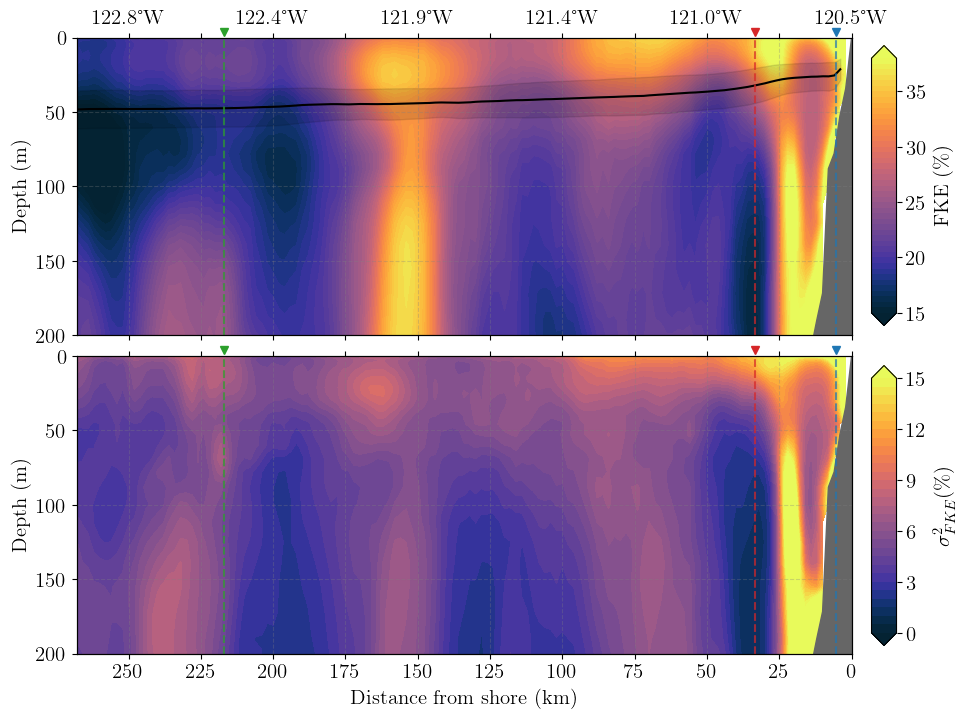

In [80]:
if option_energy == 'FKE': 

    levels_mean = np.arange(15,38+0.5,0.5)
    levels_var = np.arange(0,15+0.5,0.5)

    # Create figure
    fig, axes = plt.subplots(2,1,figsize=(10,8))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot time-mean data
    cf = ax.contourf(dist,abs(depth),data_mean*100, levels=levels_mean, cmap=cmap, extend='both')

    # Plot the 50% contour level
    #ct = ax.contour(dist,abs(depth),data_mean*100, levels=[50], colors='k', linestyles='-', linewidths=2) 

    # Plot seasonally averaged mixed layer depth
    ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

    # Plot standard deviation of mixed layer depth 
    ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

    # Plot the ocean bottom depth 
    ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

    # Set axis attributes
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,dist[-1])
    ax.set_ylim(0,200)
    ax.set_xticks(np.arange(0,250+25,25))
    ax.invert_xaxis()   
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.92, 0.52, 0.025, 0.35])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical') 
    cbar.set_label(label_mean)
    cbar.set_ticks(np.array([15, 20, 25, 30, 35]))

    # Add 50% contour level label
    #ax.clabel(ct, fmt=lambda val: f'{val:.0f}$\%$', fontsize=14, colors='k', manual=[(180, 150)])

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove bottom x-axis ticklabels
    ax.set_xticklabels([])

    #--- Subplot 2 ---# 
    ax = axes[1]

    # Plot time-mean data
    cf = ax.contourf(dist,abs(depth),data_var*100, levels=levels_var, cmap=cmap, extend='both')

    # Plot the ocean bottom depth 
    ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

    # Set axis attributes
    ax.set_xlabel('Distance from shore (km)')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,dist[-1])
    ax.set_ylim(0,200)
    ax.set_xticks(np.arange(0,250+25,25))
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.3,color='grey')

    # Set colorbar
    cax = fig.add_axes([0.92, 0.12, 0.025, 0.35])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
    cbar.set_label(label_var)
    cbar.set_ticks(np.arange(0,15+3,3))

    # --- Create top axis for longitude --- #
    ax_top = ax.twiny()

    # Make sure limits match
    ax_top.set_xlim(ax.get_xlim())

    # Choose where you want longitude ticks (same positions as distance ticks)
    dist_ticks = ax.get_xticks()

    # Interpolate longitude at those distance values
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Create labels but only keep every other one
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set ticks and labels
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels) 

    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate longtiude onto distance coordinates 
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    # Add CCE1, CCE2, and CCE3 locations 
    add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
    add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
    add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

    # Plot vertical lines at CCE1, CCE2, and CCE3 locations
    ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
    ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

    # Remove top x-axis ticklabels
    ax_top.set_xticklabels([])

    # Display 
    plt.subplots_adjust(hspace=0.07, wspace=0.1)
    plt.show()

    # Save with high quality
    figName = 'figS07_new.png'

    fig.savefig(
        PATH_figs + figName,
        dpi=300,
        facecolor='white',
        bbox_inches='tight',
        pad_inches=0.1,
        transparent=False
    )


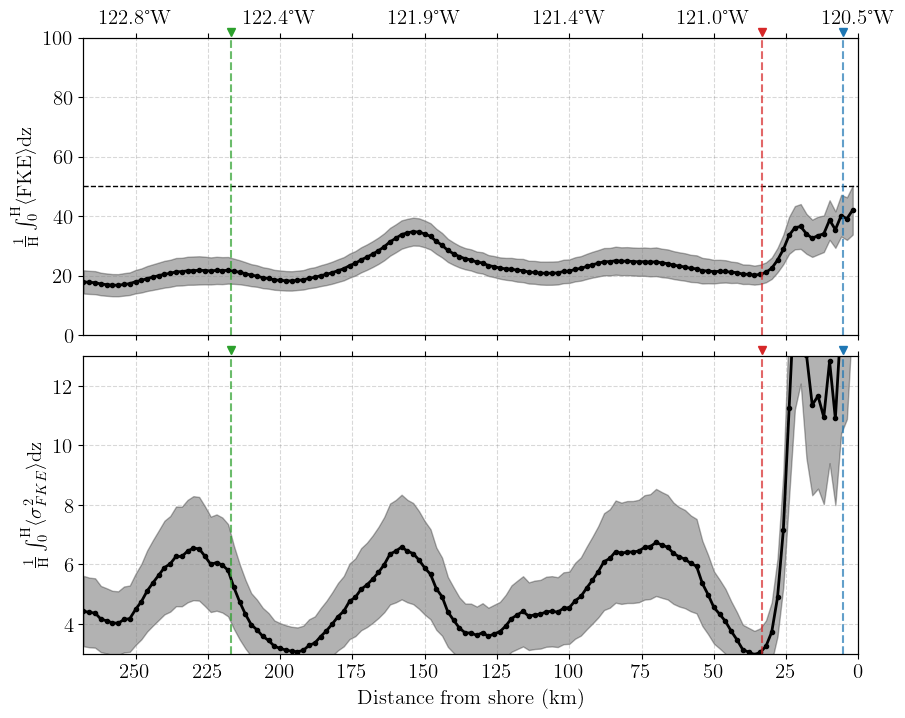

In [61]:
# Create figure
fig, axes = plt.subplots(2,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot depth integrated time-mean 
ax.plot(dist, data_mean_avg*100, '.-', color = 'k', lw=2)

# Plot the 50% contour
ax.axhline(50, color='k', ls='--', lw=1)

# Plot the standard error of the mean 
ax.fill_between(dist, data_mean_avg*100 - data_stdm_avg*100, data_mean_avg*100 + data_stdm_avg*100, color='k', alpha=0.3)

# Set axis attributes
ax.set_ylabel(r'$\frac{1}{\textrm{H}} \int_{0}^{\textrm{H}} \langle $' + option_energy + r'$\rangle$dz')
ax.set_xlim(0,dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(0,100)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot depth averaged time-mean 
ax.plot(dist, data_var_avg*100, '.-', color = 'k', lw=2)

# Plot the standard error of the mean 
ax.fill_between(dist, data_var_avg*100 - data_stdv_avg*100, data_var_avg*100 + data_stdv_avg*100, color='k', alpha=0.3)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\frac{1}{\textrm{H}} \int_{0}^{\textrm{H}} \langle \sigma_{FKE}^2\rangle$dz')
ax.set_xlim(0,dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(3,13)
ax.set_yticks(np.arange(4,12+2,2))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS08.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Plot the depth averaged velocity vectors ontop of the FKE 

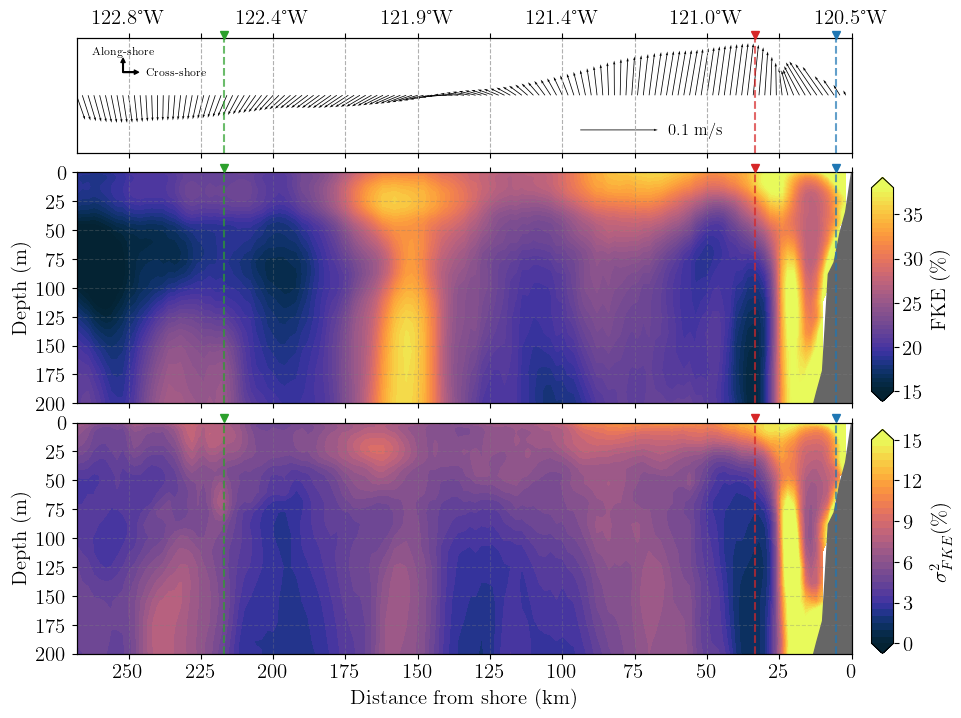

In [82]:
# Create figure
fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 2, 2]) 

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[0])

# Plot the velocity vectors
q = ax.quiver(dist, np.zeros_like(dist), u_cross_bar_mean, u_along_bar_mean, scale=1, width=0.001)

# Set axis attributes
ax.set_xlim(dist[0], dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks([])
#ax.set_xlabel('Distance from shore (km)')
ax.tick_params(top=True, bottom=True, left=False, right=False,
            direction='out', length=3.5)
ax.grid(True, linestyle='--')
ax.invert_xaxis()

# Add coordinate system arrows in top subplot
arrow_length_x,arrow_length_y = 0.02, 0.12  # adjust based on scale of your plot
x0, y0 = 0.06, 0.7    # location in axis coordinates (0–1)

# Add arrows using annotation in axis coordinates
ax.annotate('', xy=(x0 + arrow_length_x, y0), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0 + arrow_length_x + 0.01, y0, 'Cross-shore', transform=ax.transAxes,
        verticalalignment='center', fontsize=8)

ax.annotate('', xy=(x0, y0 + arrow_length_y), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0, y0 + arrow_length_y + 0.03, 'Along-shore', transform=ax.transAxes,
        horizontalalignment='center', fontsize=8)

# Set quiver legend
ax.quiverkey(q, X=0.75, Y=0.2, U=0.1, label='0.1 m/s', labelpos='E', coordinates='axes',fontproperties={'size': 12})

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[1])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),data_mean*100, levels=levels_mean, cmap=cmap, extend='both')

# Plot the 50% contour level
#ct = ax.contour(dist,abs(depth),data_mean*100, levels=[50], colors='k', linestyles='-', linewidths=2) 

# Plot seasonally averaged mixed layer depth
#ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
#ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.425, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical') 
cbar.set_label(label_mean)
cbar.set_ticks(np.array([15, 20, 25, 30, 35]))

# Add 50% contour level label
#ax.clabel(ct, fmt=lambda val: f'{val:.0f}$\%$', fontsize=14, colors='k', manual=[(180, 150)])

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top and bottom x-axis ticklabels
ax.set_xticklabels([])
ax_top.set_xticklabels([])

#--- Subplot 2 ---# 
ax = fig.add_subplot(gs[2])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),data_var*100, levels=levels_var, cmap=cmap, extend='both')

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.11, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_var)
cbar.set_ticks(np.arange(0,15+3,3))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS07.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_22692/4226243825.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


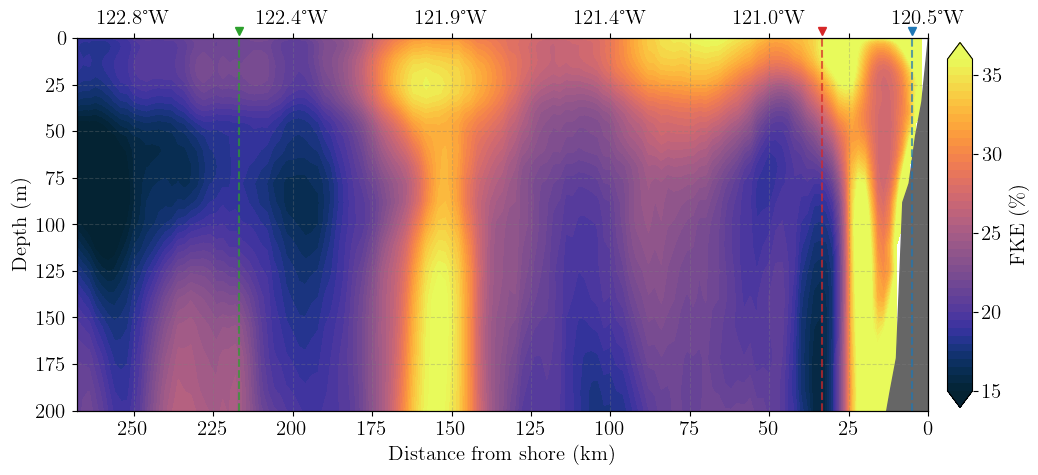

In [78]:
# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,abs(depth),data_mean*100, levels=levels_mean, cmap=cmap, extend='both')

# # Overlay a contourf with hatching for the non-significant regions
# ax.contourf(
#     dist,
#     abs(depth),
#     data_mask.T,
#     levels=[0.5, 1.5],      # anything that spans "1"
#     hatches=['///'],        # your preferred hatching style
#     colors='none',          # keep underlying colormap visible
#     linewidths=0,
#     zorder=10,              # ensure it sits above the shading
# )

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'FKE ($\%$)')
cbar.set_ticks(np.arange(15,35+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Compute the kinetic energy spectrum by taking the fourier transform of the velocity components ($E_u(f) = \lvert \hat u(f)\rvert^2$ and $E_v(f) = \lvert \hat v(f)\rvert^2$) and summing them together: 

$$
E_{KE}(f) = \frac{1}{2}(E_u + E_v)
$$

Note that this avoids spectral contamination that occurs if we were to talk the fourier transform of kinetic energy (a squared quantity). Additionally, compute the rotary coefficient from the rotary spectra: 

$$
C = \frac{S_{-} - S_{+}}{S_{-} + S_{+}}
$$

where $S_{-} = \frac{1}{2}\langle u_{-}u_{-}^{*}\rangle$ and $S_{+} = \frac{1}{2}\langle u_{+}u_{+}^{*}\rangle$ given that $u = u_1 + iu_2$ is the complex representation of the velocity vector $\textbf{u} = (u_1,u_2)$. 

In [15]:
# Set parameters
w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
segment_years = 1 
overlap       = 0.5

# Obtain a example segment 
segments_u = segment_time_series(time_dt, u_m[:,0,0], segment_years=segment_years, overlap=overlap)
segments_v = segment_time_series(time_dt, v_m[:,0,0], segment_years=segment_years, overlap=overlap)

# Set dimensions     
nseg,ntime  = np.shape(segments_u)[0], np.shape(segments_u)[2]
_,ndepth,ndist = np.shape(u_m)

# Set autocorrelation parameters
lag       = ntime
norm      = 0
estimator = 'biased'
T_days = dt*(1/60)*(1/60)*(1/24)

# Set spectral parameters
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
f_cut = 1/7                                                  # Cutoff frequency for FVE calculation units: cpd

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Initialize arrays 
S_seg           = np.zeros((ndist,ndepth,nfft))
Su_seg          = np.zeros((ndist,ndepth,nfft))
Sv_seg          = np.zeros((ndist,ndepth,nfft))
CI_seg          = np.zeros((ndist,ndepth,nfft,2))
CI_u_seg        = np.zeros((ndist,ndepth,nfft,2))
CI_v_seg        = np.zeros((ndist,ndepth,nfft,2))
C_seg           = np.zeros((ndist,ndepth,nfft))
var_anomaly     = np.zeros((ndist,ndepth))
fve_seg         = np.zeros((ndist,ndepth))

# Loop through distance offshore 
for idist in range(0,ndist):
    
    # Set progress bar
    progress = (idist + 1) / (ndist-1)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through depth
    for idepth in range(0,ndepth):
        
        # Initialize the ith time series 
        u_ts = u_m[:,idepth,idist]
        v_ts = v_m[:,idepth,idist]

        if option_vel == 'baroclinic': 

            # Remove the barotropic component (i.e., depth-averaged velocity) from the time series
            u_ts = u_ts - np.nanmean(u_m[:,:,idist], axis=1)
            v_ts = v_ts - np.nanmean(v_m[:,:,idist], axis=1)

        # Skip depth if all values are masked
        if np.all(u_ts.mask):
            continue

        # Remove annual and semi-annual cycle 
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(u_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
        u_ts_rm = u_ts - hfit

        hfit, x_data, x_data_sigma, _ = unweighted_lsf(v_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
        v_ts_rm = v_ts - hfit

        # Segment the time series 
        segments_u = segment_time_series(time_dt, u_ts_rm, segment_years=segment_years, overlap=overlap)
        segments_v = segment_time_series(time_dt, v_ts_rm, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        Su_seg_tmp      = np.full((nseg,nfft), np.nan)
        Sv_seg_tmp      = np.full((nseg,nfft), np.nan)
        S_plus_ccw_tmp  = np.full((nseg,nfft), np.nan)
        S_minus_cw_tmp  = np.full((nseg,nfft), np.nan)
        C_seg_tmp       = np.full((nseg,nfft), np.nan)
        CI_u_seg_tmp    = np.zeros((nseg,nfft,2))
        CI_v_seg_tmp    = np.zeros((nseg,nfft,2))
        CI_ccw_tmp      = np.zeros((nseg,nfft,2))
        CI_cw_tmp       = np.zeros((nseg,nfft,2))
        var_u_seg_anom  = np.zeros((nseg,1))
        var_v_seg_anom  = np.zeros((nseg,1))
        var_seg_anom    = np.zeros((nseg,1))

        # Loop through segments
        for i, ((tseg_u, useg), (tseg_v, vseg)) in enumerate(zip(segments_u, segments_v)):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg_u[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg_u])
            
            # Detrend both components
            u_dt = detrend(useg, time_elapsed_seg, mean=0)
            v_dt = detrend(vseg, time_elapsed_seg, mean=0)

            # Compute frequency power spectrum
            Su_seg_tmp[i,:], f_seg, CI_u_seg_tmp[i,:], _ = spectrum1D_frequency(u_dt, dt, M, units)
            Sv_seg_tmp[i,:], _,     CI_v_seg_tmp[i,:], _ = spectrum1D_frequency(v_dt, dt, M, units)

            # Compute the rotary power spectra 
            S_plus_ccw_tmp[i,:], S_minus_cw_tmp[i,:], _, CI_ccw_tmp[i,:], CI_cw_tmp[i,:], _ = rotary_spectrum_welch(u_dt, v_dt, dt, M, units='cpd')

            # Compute the rotary coefficient 
            C_seg_tmp[i,:] = (S_minus_cw_tmp[i,:] - S_plus_ccw_tmp[i,:])/(S_minus_cw_tmp[i,:] + S_plus_ccw_tmp[i,:])

            # Compute the variance of the ith segment 
            var_u_seg_anom[i] = np.var(u_dt, ddof=1)
            var_v_seg_anom[i] = np.var(v_dt, ddof=1)

            # Compute the total variance of the segment (i.e., sum of the variance of the two components)
            var_seg_anom[i] = 1/2 * (var_u_seg_anom[i] + var_v_seg_anom[i])

        # Compute the mean variance between segments and its uncertainty 
        var_anomaly[idist,idepth]     = np.mean(var_seg_anom)

        # Compute the mean frequency spectrum and convert to cycles per day
        Su_seg[idist,idepth,:] = np.nanmean(Su_seg_tmp, axis=0)/(60 * 60 * 24)
        Sv_seg[idist,idepth,:] = np.nanmean(Sv_seg_tmp, axis=0)/(60 * 60 * 24)
        C_seg[idist,idepth,:] = np.nanmean(C_seg_tmp, axis=0)

        # Compute the mean frequency spectrum of the kinetic energy 
        S_seg[idist,idepth,:]  = 1/2 * (Su_seg[idist,idepth,:] + Sv_seg[idist,idepth,:])
        f_cpd_seg = f_seg*(60*60*24)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_u_seg[idist,idepth,:,:] = np.column_stack((error_low * Su_seg[idist,idepth,:], error_high * Su_seg[idist,idepth,:]))
        CI_v_seg[idist,idepth,:,:] = np.column_stack((error_low * Sv_seg[idist,idepth,:], error_high * Sv_seg[idist,idepth,:]))

        #-------------------------------------# 
        # Compute the fraction of variance explained by the high-frequency variability 
        #-------------------------------------# 
        
        # Create frequency mask for high and low frequency bands
        mask_low  = f_cpd_seg <= f_cut
        mask_high = ~mask_low

        # Compute frequency spacing (IMPORTANT)
        df = np.gradient(f_cpd_seg)

        # Apply masks and integrate over frequency axis
        var_high_m = np.sum(S_seg[idist,idepth,:] * mask_high * df)

        # Compute the fraction of variance explained by the high-frequency variability 
        fve_seg[idist,idepth] = var_high_m/var_anomaly[idist,idepth]


Progress: 100.7%

Compute the depth averaged rotary coefficient

In [17]:
S_seg_mean = np.nanmean(S_seg, axis=1)
C_seg_mean = np.nanmean(C_seg, axis=1)

Plot the FVE across the transect

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_73865/2603207547.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


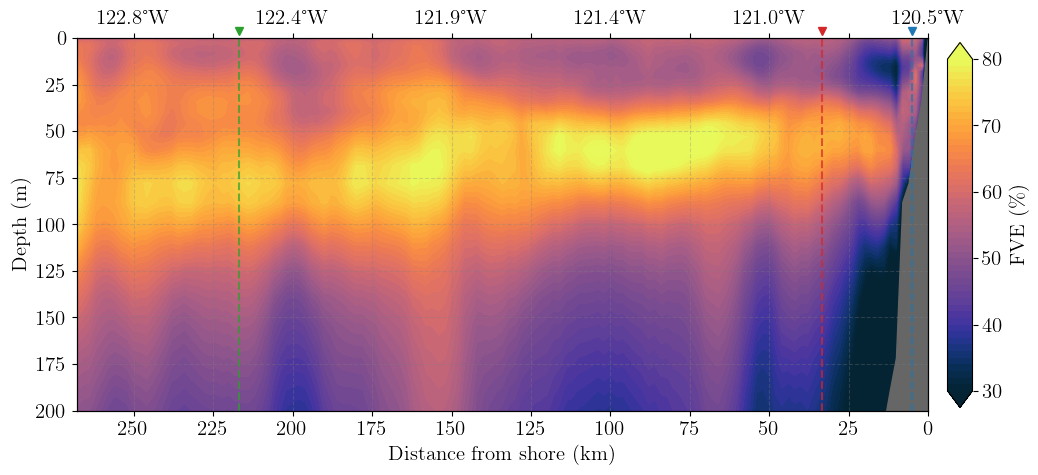

In [19]:
# Set plotting parameter
level = np.arange(30,80+1,1) #np.arange(0,40+1,1) 

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,abs(depth),(fve_seg*100).T, levels=level, cmap=cmo.thermal, extend='both')

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'FVE ($\%$)')
cbar.set_ticks(np.arange(30,80+10,10)) #cbar.set_ticks(np.arange(0,40+10,10)) 

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig40.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Plot a depth kinetic energy spectrogram at closest sites along the CalCOFI line 80 transect

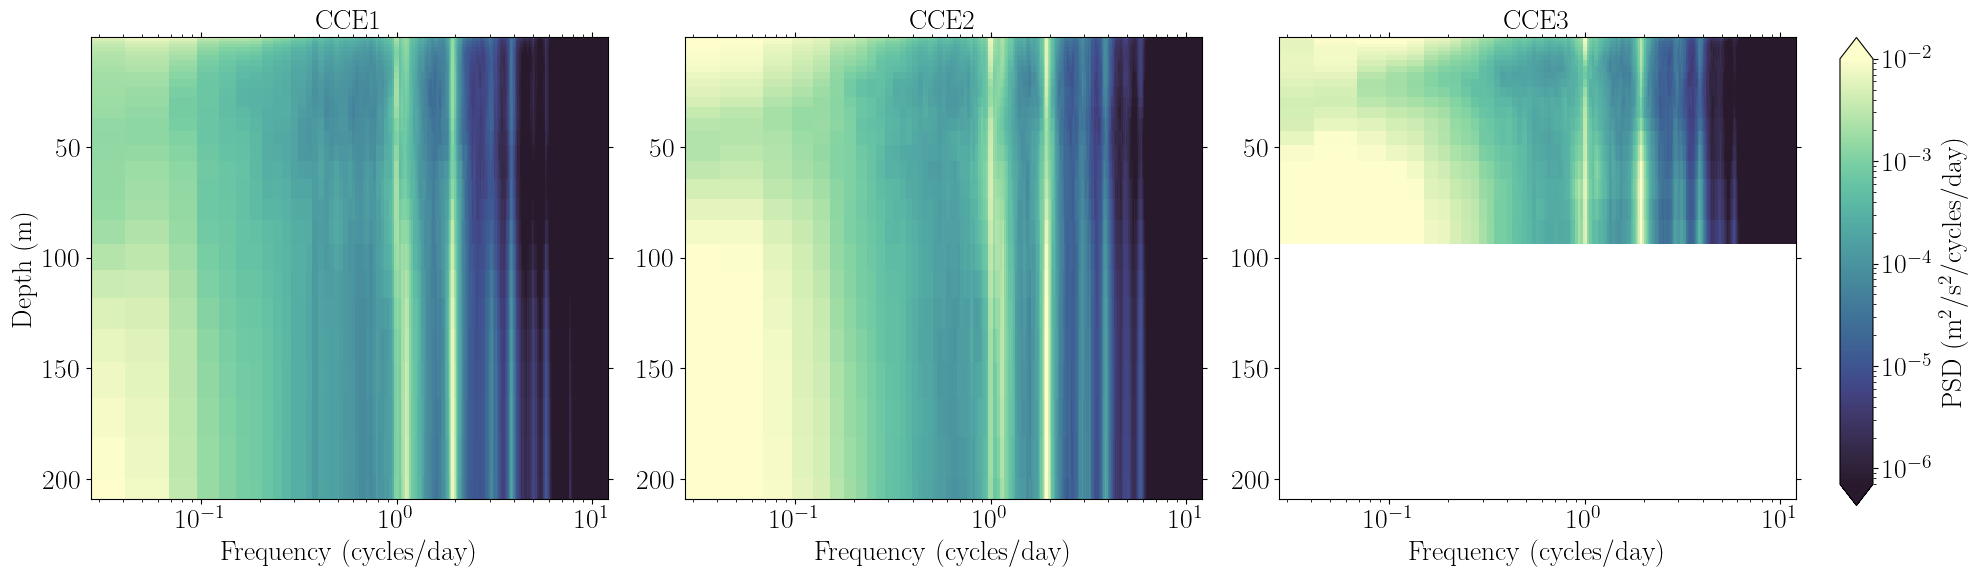

In [20]:
# Find the indicies closest to the CCE locations
dist1_idx = np.argmin(np.abs(dist - dist1))
dist2_idx = np.argmin(np.abs(dist - dist2))
dist3_idx = np.argmin(np.abs(dist - dist3))

# Set colormap and levels
cmap = cmo.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=1e-2) #mcolors.LogNorm(vmin=7e-7, vmax=2e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_seg, abs(depth))

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 6))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 kinetic energy spectrogram 
pc = ax1.pcolormesh(F_m,D_m,S_seg[dist1_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax1.set_title('CCE1', fontsize=fontsize)
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax1.set_ylim(abs(depth[0]),abs(depth[-1]))
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 kinetic energy spectrogram 
pc = ax2.pcolormesh(F_m,D_m,S_seg[dist2_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax2.set_title('CCE2', fontsize=fontsize)
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax2.set_ylim(abs(depth[0]),abs(depth[-1]))
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE3 kinetic energy spectrogram
pc = ax3.pcolormesh(F_m,D_m,S_seg[dist3_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax3.set_title('CCE3', fontsize=fontsize)
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax3.set_ylim(abs(depth[0]),abs(depth[-1]))
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (m$^2$/s$^2$/cycles/day)')

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.15)
plt.show()

Plot the individual velocity component spectra for CCE1, CCE2, and CCE3 locations

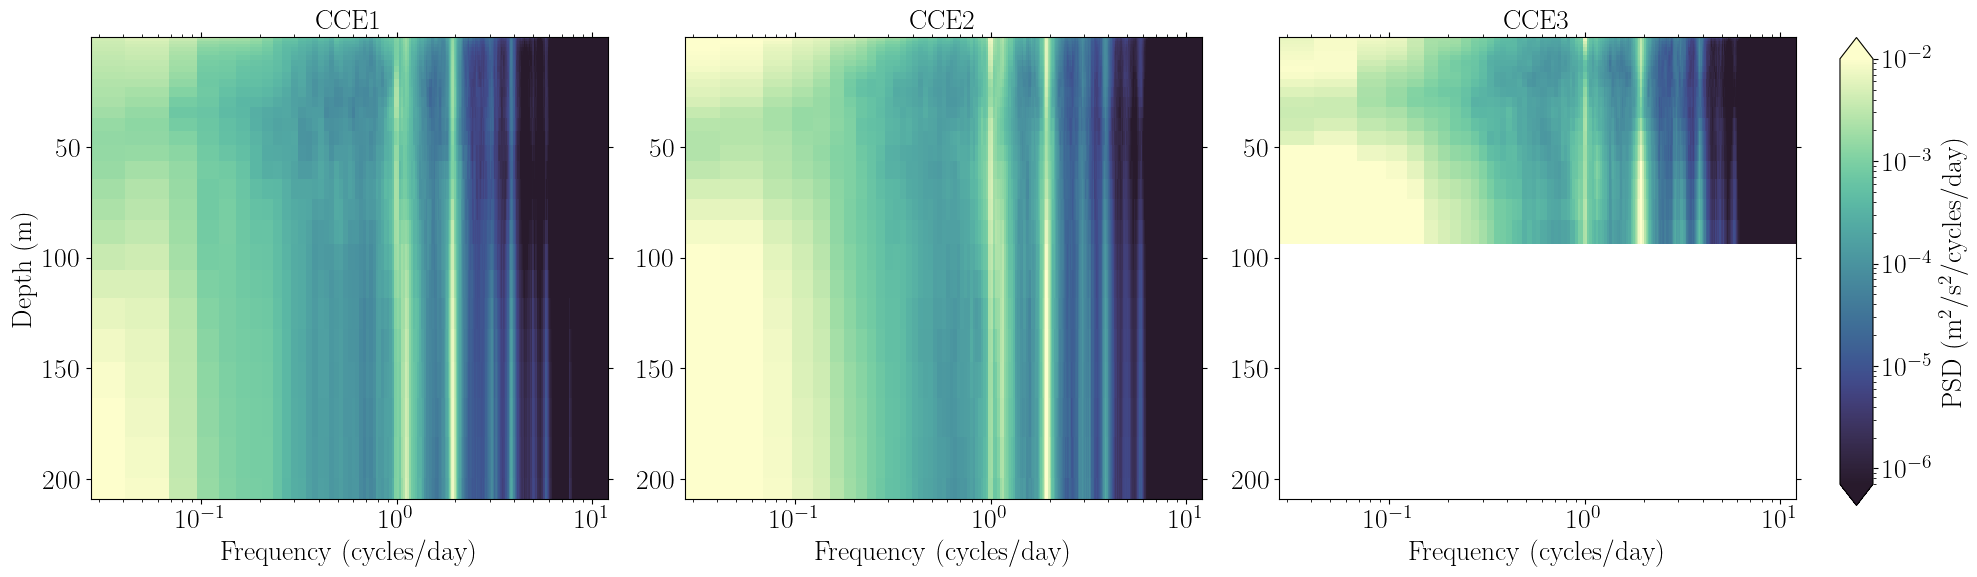

In [21]:
# Find the indicies closest to the CCE locations
dist1_idx = np.argmin(np.abs(dist - dist1))
dist2_idx = np.argmin(np.abs(dist - dist2))
dist3_idx = np.argmin(np.abs(dist - dist3))

# Set colormap and levels
cmap = cmo.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=1e-2) #mcolors.LogNorm(vmin=7e-7, vmax=2e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_seg, abs(depth))

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 6))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 kinetic energy spectrogram 
pc = ax1.pcolormesh(F_m,D_m,Su_seg[dist1_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax1.set_title('CCE1', fontsize=fontsize)
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax1.set_ylim(abs(depth[0]),abs(depth[-1]))
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 kinetic energy spectrogram 
pc = ax2.pcolormesh(F_m,D_m,S_seg[dist2_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax2.set_title('CCE2', fontsize=fontsize)
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax2.set_ylim(abs(depth[0]),abs(depth[-1]))
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE3 kinetic energy spectrogram
pc = ax3.pcolormesh(F_m,D_m,Su_seg[dist3_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax3.set_title('CCE3', fontsize=fontsize)
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax3.set_ylim(abs(depth[0]),abs(depth[-1]))
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (m$^2$/s$^2$/cycles/day)')

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.15)
plt.show()

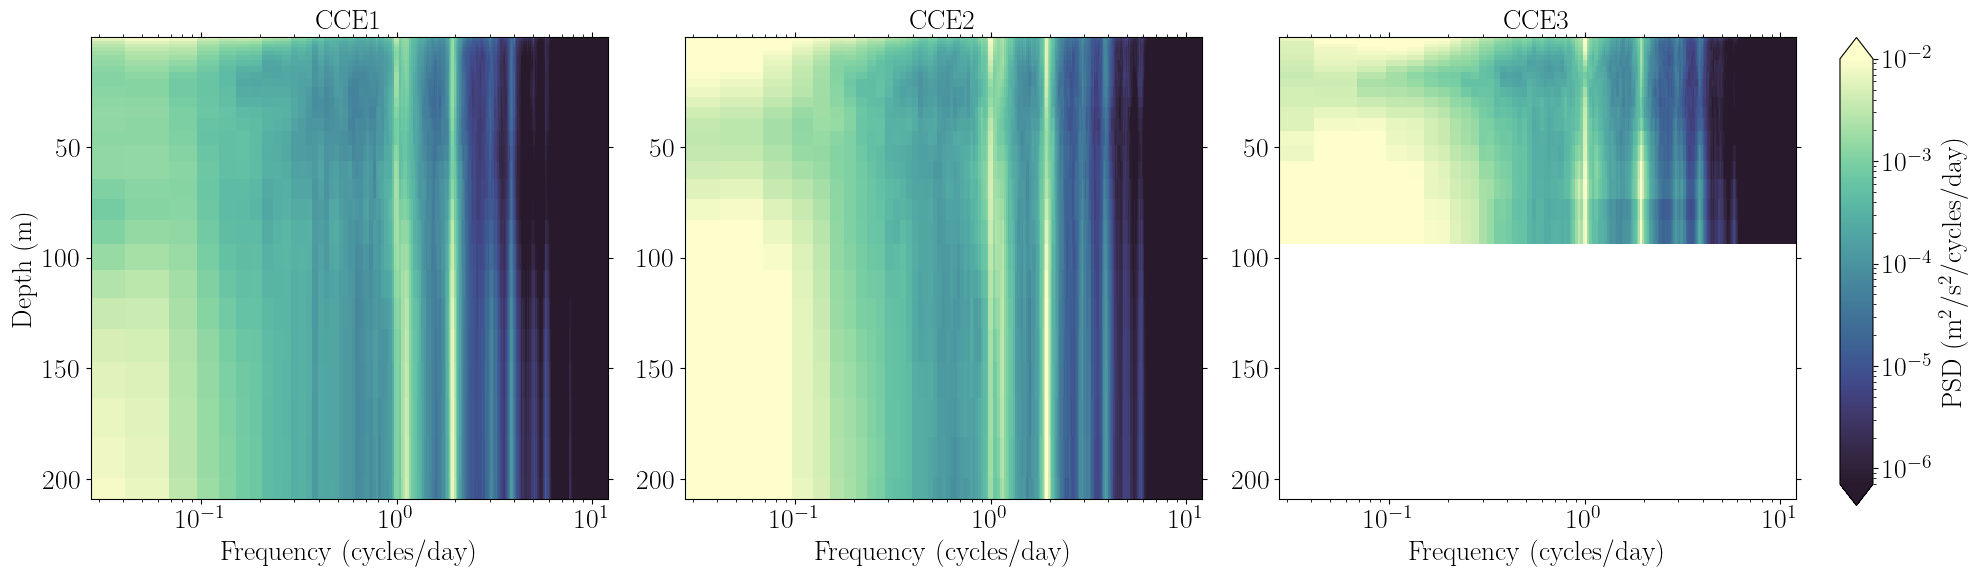

In [22]:
# Find the indicies closest to the CCE locations
dist1_idx = np.argmin(np.abs(dist - dist1))
dist2_idx = np.argmin(np.abs(dist - dist2))
dist3_idx = np.argmin(np.abs(dist - dist3))

# Set colormap and levels
cmap = cmo.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=1e-2) #mcolors.LogNorm(vmin=7e-7, vmax=2e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_seg, abs(depth))

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 6))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 kinetic energy spectrogram 
pc = ax1.pcolormesh(F_m,D_m,Sv_seg[dist1_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax1.set_title('CCE1', fontsize=fontsize)
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax1.set_ylim(abs(depth[0]),abs(depth[-1]))
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 kinetic energy spectrogram 
pc = ax2.pcolormesh(F_m,D_m,Sv_seg[dist2_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax2.set_title('CCE2', fontsize=fontsize)
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax2.set_ylim(abs(depth[0]),abs(depth[-1]))
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE3 kinetic energy spectrogram
pc = ax3.pcolormesh(F_m,D_m,Sv_seg[dist3_idx,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax3.set_title('CCE3', fontsize=fontsize)
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax3.set_ylim(abs(depth[0]),abs(depth[-1]))
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (m$^2$/s$^2$/cycles/day)')

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.15)
plt.show()

Plot the rotary cofficient spectrum 

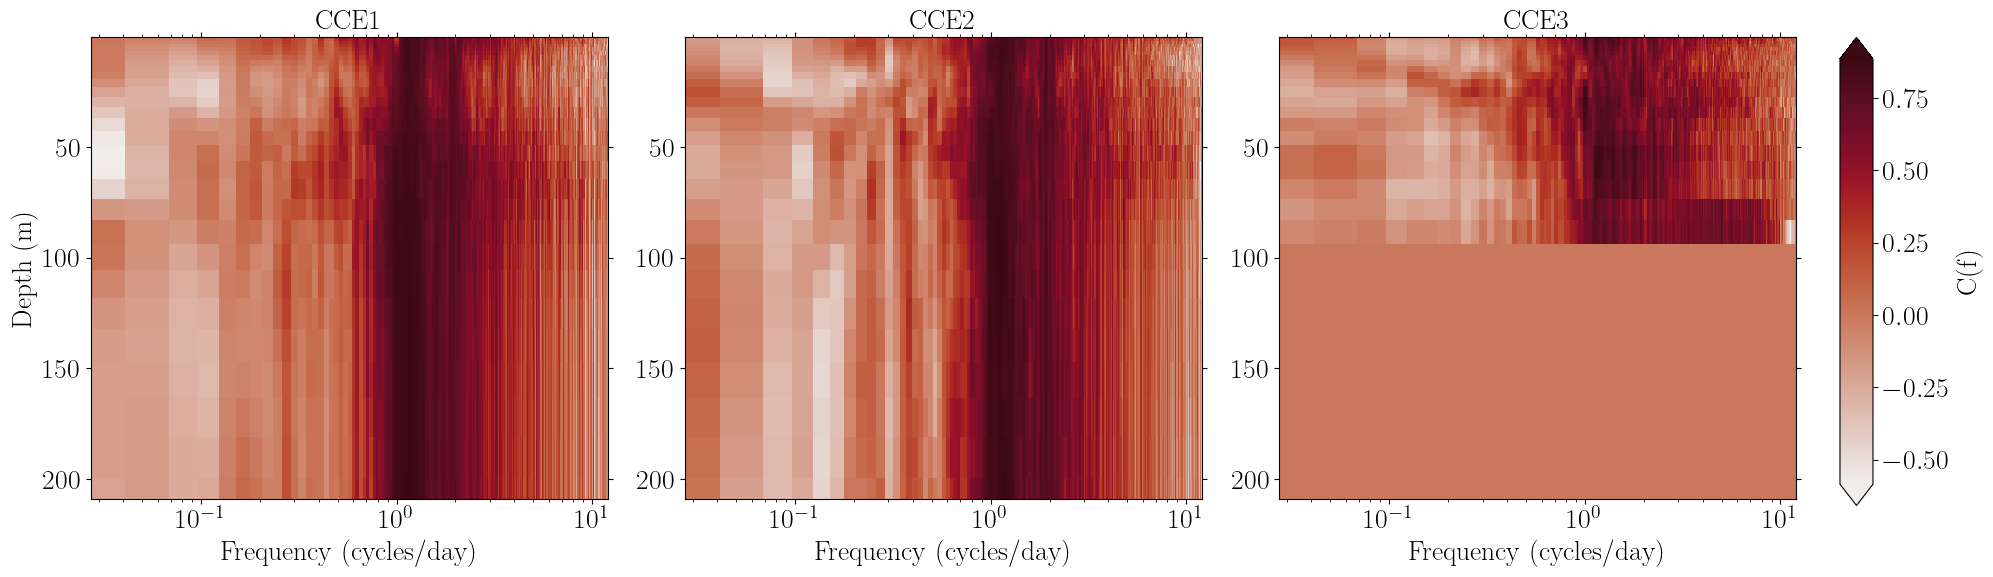

In [23]:
# Find the indicies closest to the CCE locations
dist1_idx = np.argmin(np.abs(dist - dist1))
dist2_idx = np.argmin(np.abs(dist - dist2))
dist3_idx = np.argmin(np.abs(dist - dist3))

# Set colormap and levels
cmap = cmo.amp

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_seg, abs(depth))

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 6))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 kinetic energy spectrogram 
pc = ax1.pcolormesh(F_m,D_m,C_seg[dist1_idx,:,:],cmap=cmap,shading='auto')

# Set figure attributes
ax1.set_title('CCE1', fontsize=fontsize)
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax1.set_ylim(abs(depth[0]),abs(depth[-1]))
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 kinetic energy spectrogram 
pc = ax2.pcolormesh(F_m,D_m,C_seg[dist2_idx,:,:],cmap=cmap,shading='auto')

# Set figure attributes
ax2.set_title('CCE2', fontsize=fontsize)
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax2.set_ylim(abs(depth[0]),abs(depth[-1]))
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE3 kinetic energy spectrogram
pc = ax3.pcolormesh(F_m,D_m,C_seg[dist3_idx,:,:],cmap=cmap,shading='auto')

# Set figure attributes
ax3.set_title('CCE3', fontsize=fontsize)
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax3.set_ylim(abs(depth[0]),abs(depth[-1]))
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'C(f)')

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.15)
plt.show()

Plot the depth averaged rotary spectrum 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_73865/3434391322.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


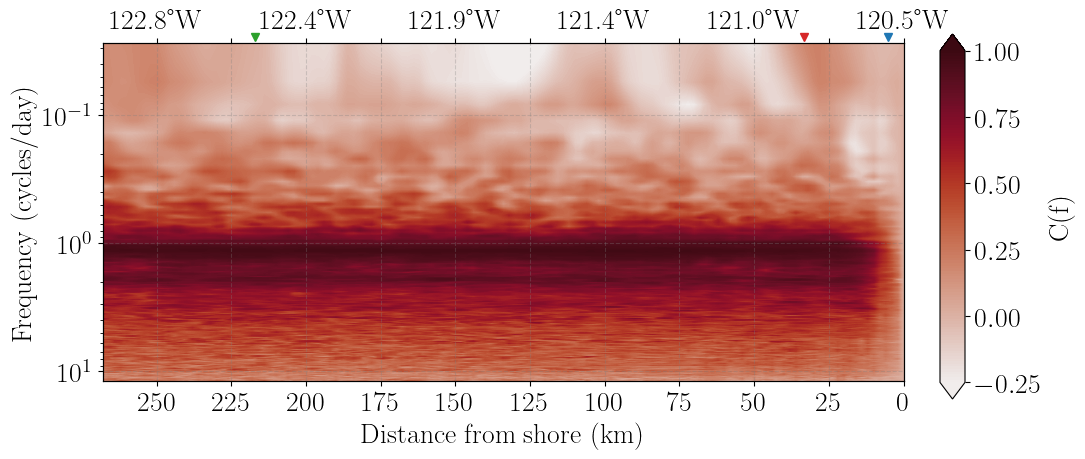

In [24]:
# Set plotting parameter
level = np.arange(-0.25,1+0.01,0.01)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,f_cpd_seg,C_seg_mean.T, levels=level, cmap=cmo.amp, extend='both')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'C(f)')
cbar.set_ticks(np.arange(-0.25,1+0.25,0.25))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
# ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
# ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
# ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


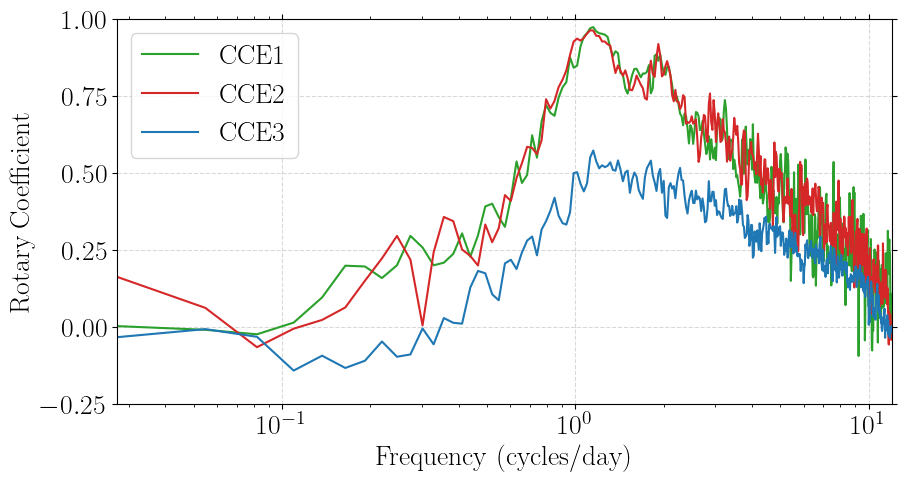

In [25]:
# Create figure and axes 
fig, ax = plt.subplots(figsize=(10,5))

# Plot the rotary coefficient spectrum 
ax.semilogx(f_cpd_seg, C_seg_mean[dist1_idx,:], label='CCE1', color='tab:green')
ax.semilogx(f_cpd_seg, C_seg_mean[dist2_idx,:], label='CCE2', color='tab:red')
ax.semilogx(f_cpd_seg, C_seg_mean[dist3_idx,:], label='CCE3', color='tab:blue')    

# Set figure attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_ylabel('Rotary Coefficient')
ax.set_xlim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_ylim(-0.25,1)
ax.legend(loc='upper left')
ax.grid(linestyle='--',alpha=0.3,color='grey')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)   

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_73865/1541469868.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(dist,f_cpd_seg,S_seg_mean.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_73865/1541469868.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


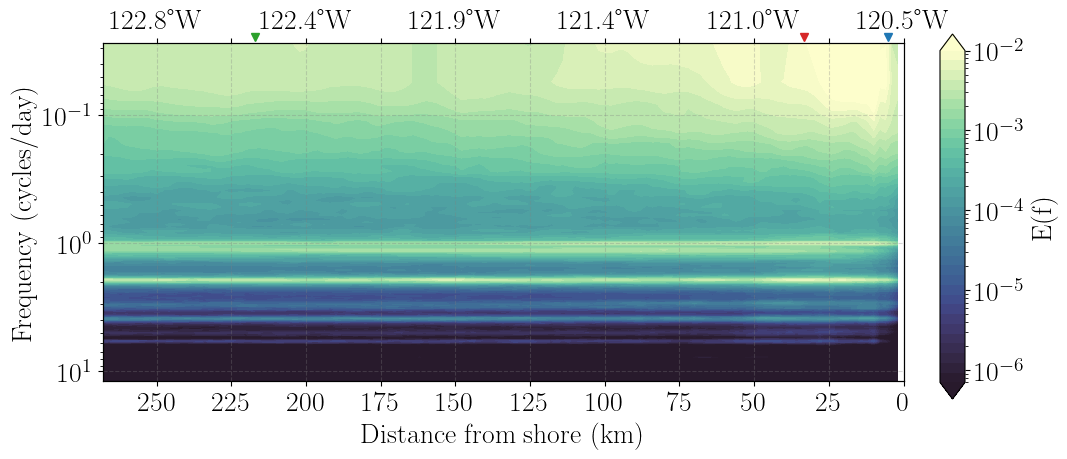

In [26]:
# Set plotting parameter
levels = np.logspace(np.log10(7e-7), np.log10(1e-2), num=35)

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=1e-2)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,f_cpd_seg,S_seg_mean.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(r'E(f)')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
# ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
# ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
# ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Save data in a npz file 

In [27]:
# Check if file exists, then delete it
if option_vel == 'baroclinic':
    file_KE_path = PATH + "mitgcm_transect_ke_baroclinic.npz"
else: 
    file_KE_path = PATH + "mitgcm_transect_ke.npz"
if os.path.exists(file_KE_path):
    os.remove(file_KE_path)

# Set metadata
metadata = {
    'description': 'Kinetic energy depth spectrogram and fraction of Kinetic energy explained by high frequency variability greater than 1 week at the three CCE mooring locations.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}
    
# Save data arrays and metadata to a .npz file
np.savez(file_KE_path,
    S_ke              = S_seg,
    S_u               = Su_seg,
    S_v               = Sv_seg,
    CI_ke              = CI_seg,
    CI_u              = CI_u_seg,
    CI_v              = CI_v_seg,
    C_coef            = C_seg,
    FKE               = fve_seg,
    var_anom          = var_anomaly,
    lon               = lon,
    lat               = lat,
    depth             = depth,
    dist              = dist,
    f_cpd             = f_cpd_seg,
    metadata          = metadata
    )